# Exploartory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
print('All imports successful')

All imports successful


In [2]:
import os
os.getcwd()

'C:\\Users\\DELL'

In [3]:
orig_path = r'E:\Graduation Project\AgriVision\AI\Irrigation-Recommendation-ML-Model\data\raw\irrigation_prediction.csv'
train_path = r'E:\Graduation Project\AgriVision\AI\Irrigation-Recommendation-ML-Model\data\raw\train.csv'
test_path = r'E:\Graduation Project\AgriVision\AI\Irrigation-Recommendation-ML-Model\data\raw\test.csv'

orig_df = pd.read_csv(orig_path)
train_df = pd.read_csv(train_path).dropna(subset=['Irrigation_Need'])
test_df = pd.read_csv(test_path)

print(f'Train:     {train_df.shape}')
print(f'Test:      {test_df.shape}')
print(f'Original:  {orig_df.shape}')

Train:     (630000, 21)
Test:      (270000, 20)
Original:  (10000, 20)


In [4]:
# Add id column to original
# orig_df['id'] = range(train_df['id'].max() + 1, train_df['id'].max() + 1 + len(orig_df))

# Blend: concat original data with training data
# train_full = pd.concat([train_df, orig_df], axis=0, ignore_index=True)
# print(f'Blended train:     {train_full.shape}')
# print(f'\nTarget distribution (blended):')
# print(train_full['Irrigation_Need'].value_counts(normalize=True))

In [5]:
orig_df = orig_df[["Crop_Type","Crop_Growth_Stage", "Season",  "gSoil_Type", "Rainfall_mm", "Humidity", "Soil_Moisture","Temperature_C", "Field_Area_hectare", "Soil_pH", "Electrical_Conductivity", "Irrigation_Need"]] 

In [6]:
orig_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Crop_Type                10000 non-null  object 
 1   Crop_Growth_Stage        10000 non-null  object 
 2   Season                   10000 non-null  object 
 3   gSoil_Type               10000 non-null  object 
 4   Rainfall_mm              10000 non-null  float64
 5   Humidity                 10000 non-null  float64
 6   Soil_Moisture            10000 non-null  float64
 7   Temperature_C            10000 non-null  float64
 8   Field_Area_hectare       10000 non-null  float64
 9   Soil_pH                  10000 non-null  float64
 10  Electrical_Conductivity  10000 non-null  float64
 11  Irrigation_Need          10000 non-null  object 
dtypes: float64(7), object(5)
memory usage: 937.6+ KB


In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [8]:
orig_df.head(10)

,Crop_Type,Crop_Growth_Stage,Season,gSoil_Type,Rainfall_mm,Humidity,Soil_Moisture,Temperature_C,Field_Area_hectare,Soil_pH,Electrical_Conductivity,Irrigation_Need
0,Wheat,Vegetative,Rabi,Clay,1167.70,31.19,36.48,21.90,4.73,6.14,2.17,Low
1,Maize,Flowering,Zaid,Silt,831.28,26.01,50.56,36.50,12.22,6.41,0.23,Medium
2,Cotton,Harvest,Rabi,Sandy,1844.45,76.41,40.07,41.83,5.52,7.71,2.18,Low
3,Wheat,Sowing,Kharif,Clay,306.26,43.32,12.75,37.22,1.43,5.96,0.40,Medium
4,Cotton,Sowing,Zaid,Clay,1875.63,86.44,18.58,22.38,2.52,7.76,2.52,Medium
5,Rice,Sowing,Zaid,Silt,402.92,62.51,20.50,33.34,7.56,5.10,1.43,Medium
6,Rice,Flowering,Kharif,Sandy,764.95,58.50,22.70,28.02,2.18,7.44,2.95,Medium
7,Wheat,Vegetative,Zaid,Sandy,833.33,79.10,40.23,35.60,12.54,7.68,3.30,Low
8,Maize,Flowering,Kharif,Clay,2476.03,76.88,36.73,16.59,13.75,5.42,1.52,Low
9,Rice,Vegetative,Rabi,Loamy,1474.55,74.30,19.58,31.14,1.27,6.26,1.67,Medium


In [9]:
orig_df.describe(include='all')

,Crop_Type,Crop_Growth_Stage,Season,gSoil_Type,Rainfall_mm,Humidity,Soil_Moisture,Temperature_C,Field_Area_hectare,Soil_pH,Electrical_Conductivity,Irrigation_Need
count,10000,10000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,6,4,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Rice,Harvest,Rabi,Sandy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,1711,2581,3383,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5864
mean,NaN,NaN,NaN,NaN,1252.499420,60.080339,36.969207,26.991423,7.598024,6.487857,1.791963,NaN
std,NaN,NaN,NaN,NaN,715.582201,20.187973,16.430845,8.664074,4.233919,0.979963,0.984202,NaN
min,NaN,NaN,NaN,NaN,0.380000,25.000000,8.000000,12.000000,0.300000,4.800000,0.100000,NaN
25%,NaN,NaN,NaN,NaN,634.155000,42.855000,22.860000,19.460000,3.950000,5.640000,0.940000,NaN
50%,NaN,NaN,NaN,NaN,1250.335000,60.040000,37.240000,27.090000,7.540000,6.470000,1.780000,NaN
75%,NaN,NaN,NaN,NaN,1880.265000,77.705000,50.940000,34.500000,11.202500,7.350000,2.650000,NaN


## Target Distribution: **Irrigation_Need**

In [10]:
print(f'\nTarget distribution:')
print(orig_df['Irrigation_Need'].value_counts(normalize=True))


Target distribution:
Irrigation_Need
Low       0.5864
Medium    0.3800
High      0.0336
Name: proportion, dtype: float64


In [11]:
categorical_cols = orig_df.select_dtypes(include=['object']).columns
numerical_cols = orig_df.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Crop_Type', 'Crop_Growth_Stage', 'Season', 'gSoil_Type',
       'Irrigation_Need'],
      dtype='object')
Numerical Columns: Index(['Rainfall_mm', 'Humidity', 'Soil_Moisture', 'Temperature_C',
       'Field_Area_hectare', 'Soil_pH', 'Electrical_Conductivity'],
      dtype='object')


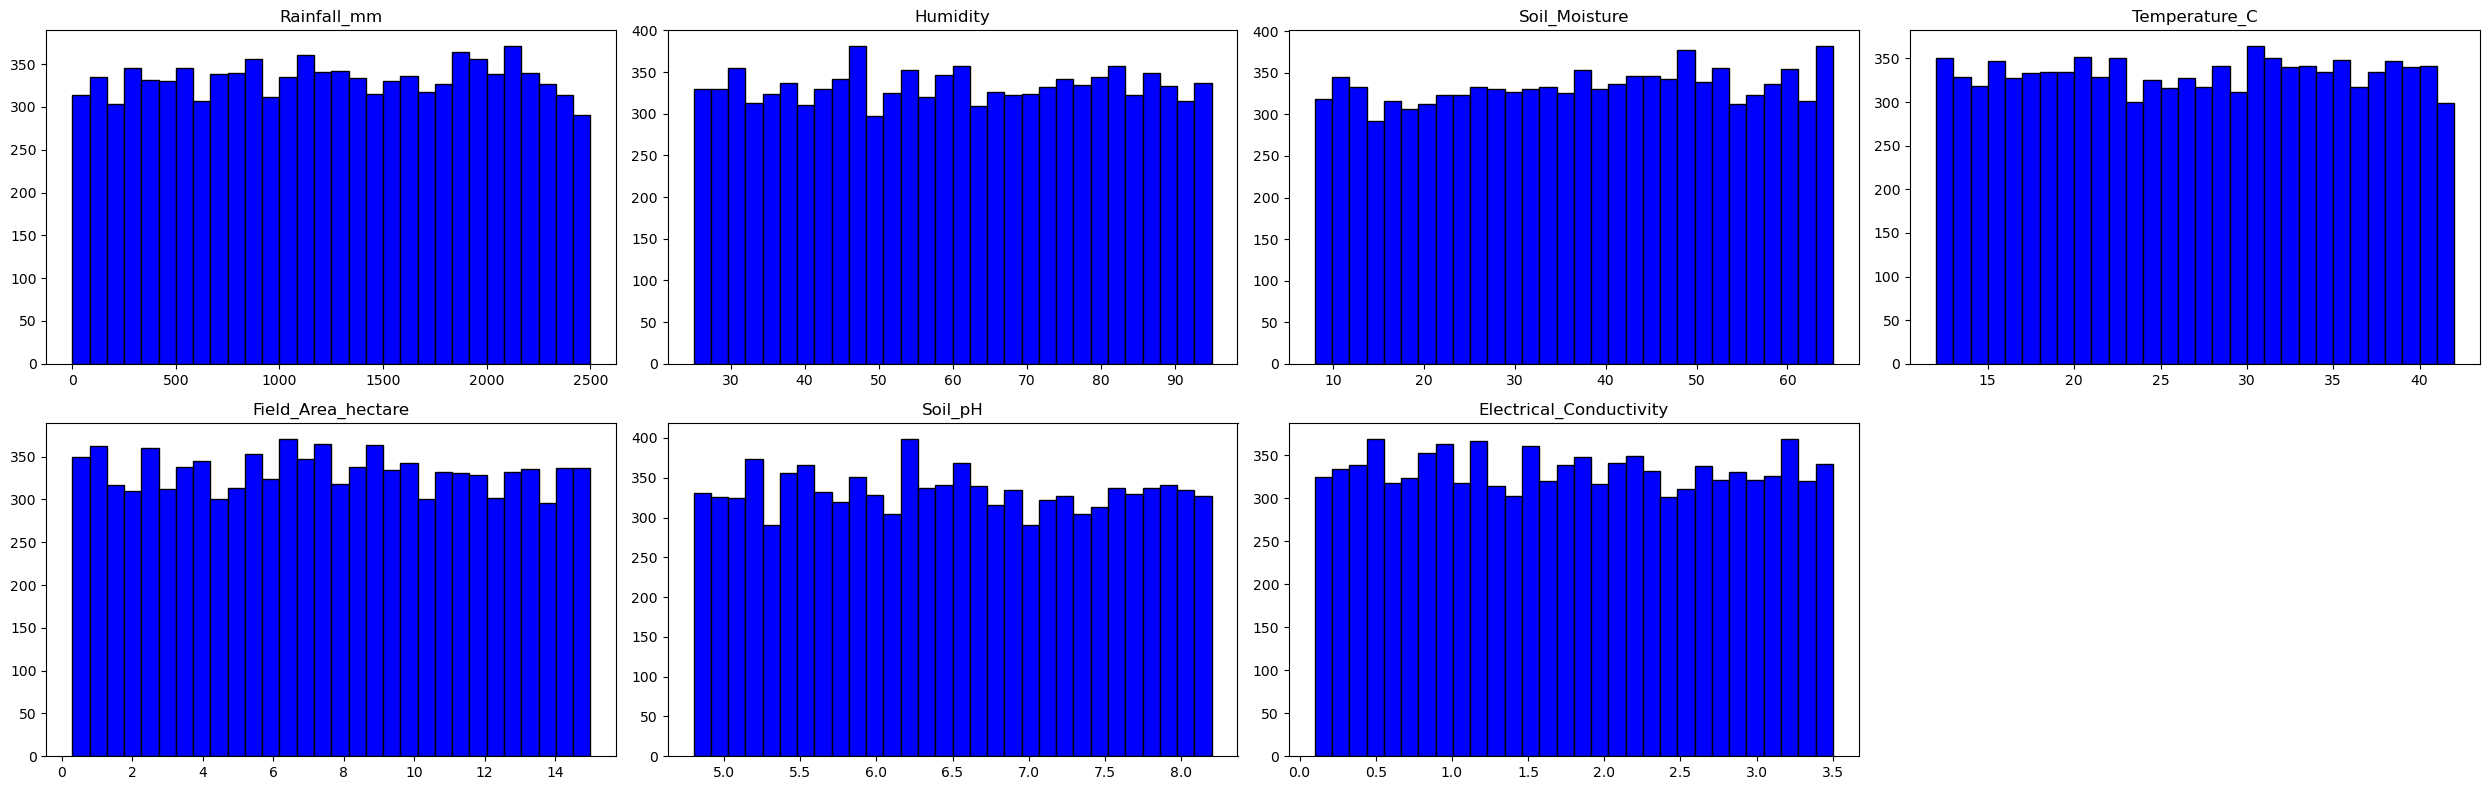

In [35]:
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(25, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[:7]):
    data = orig_df[col].dropna()

    counts, bins, _ = axes[i].hist(
        data,
        bins=30,
        color='blue',
        edgecolor='black'
    )

    centers = (bins[:-1] + bins[1:]) / 2

    axes[i].set_title(col)

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

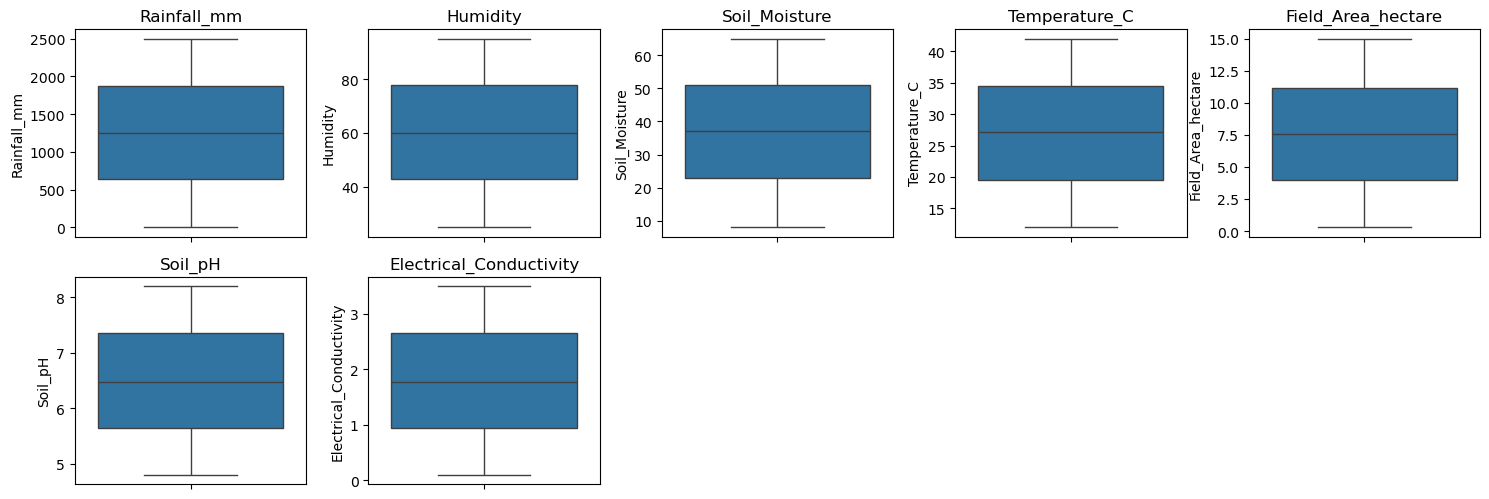

In [22]:
# Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,5,i+1)
    sns.boxplot(y=orig_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

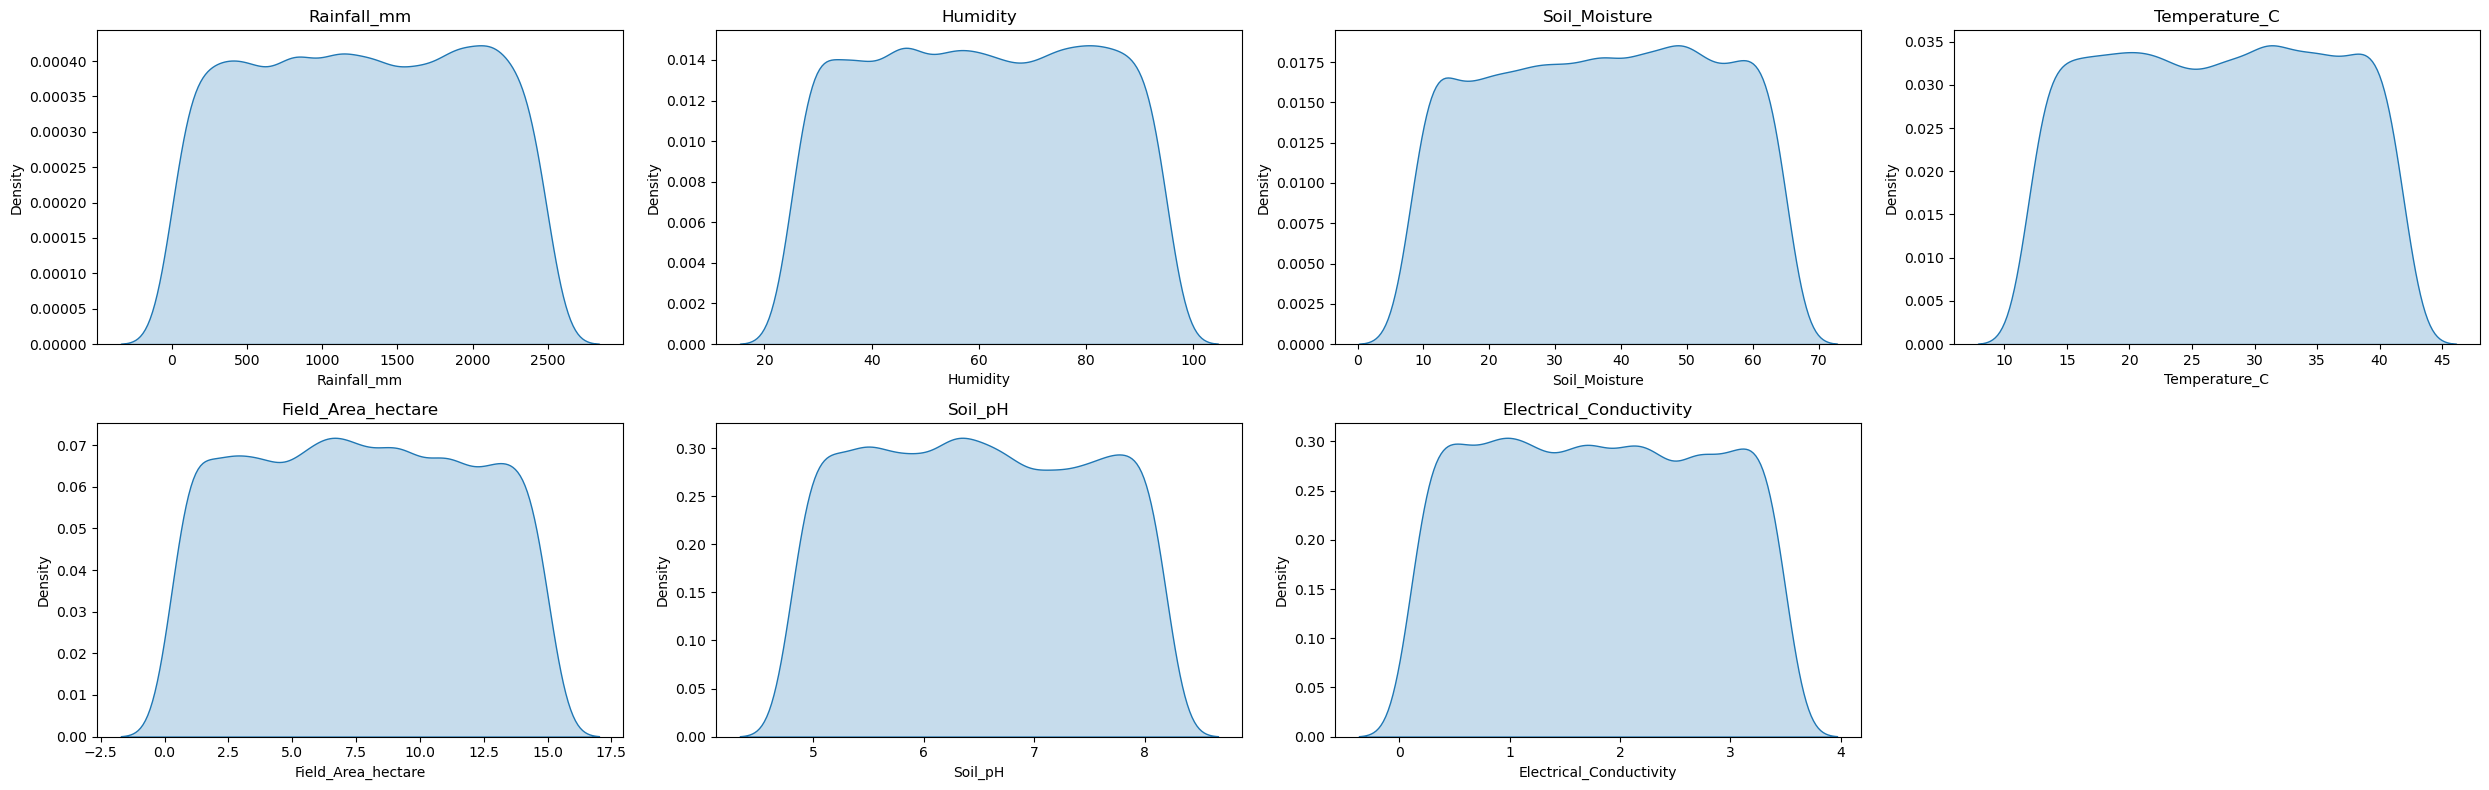

In [41]:
# KDE Plots
plt.figure(figsize=(25,8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,4,i+1)
    sns.kdeplot(orig_df[col], shade=True)
    plt.title(col)
plt.tight_layout()
plt.show()

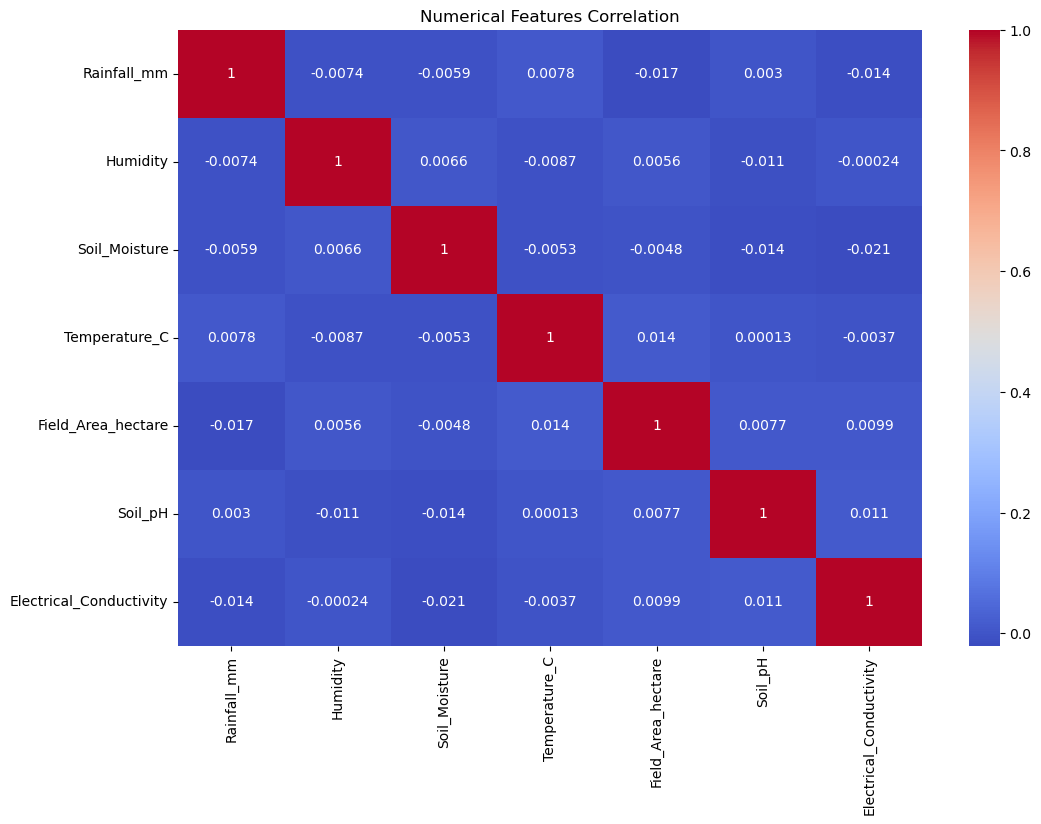

In [42]:
# Heatmap for correlation
plt.figure(figsize=(12,8))
sns.heatmap(orig_df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Numerical Features Correlation")
plt.show()

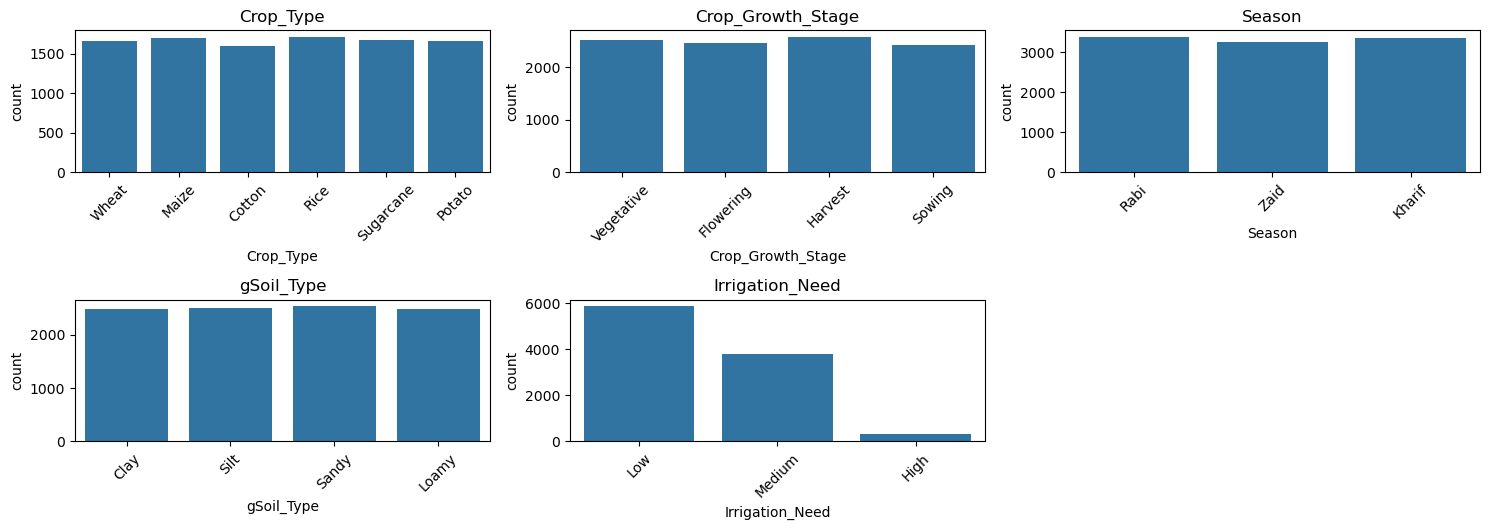

In [43]:
# Countplots / Barplots
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(4,3,i+1)
    sns.countplot(data=orig_df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

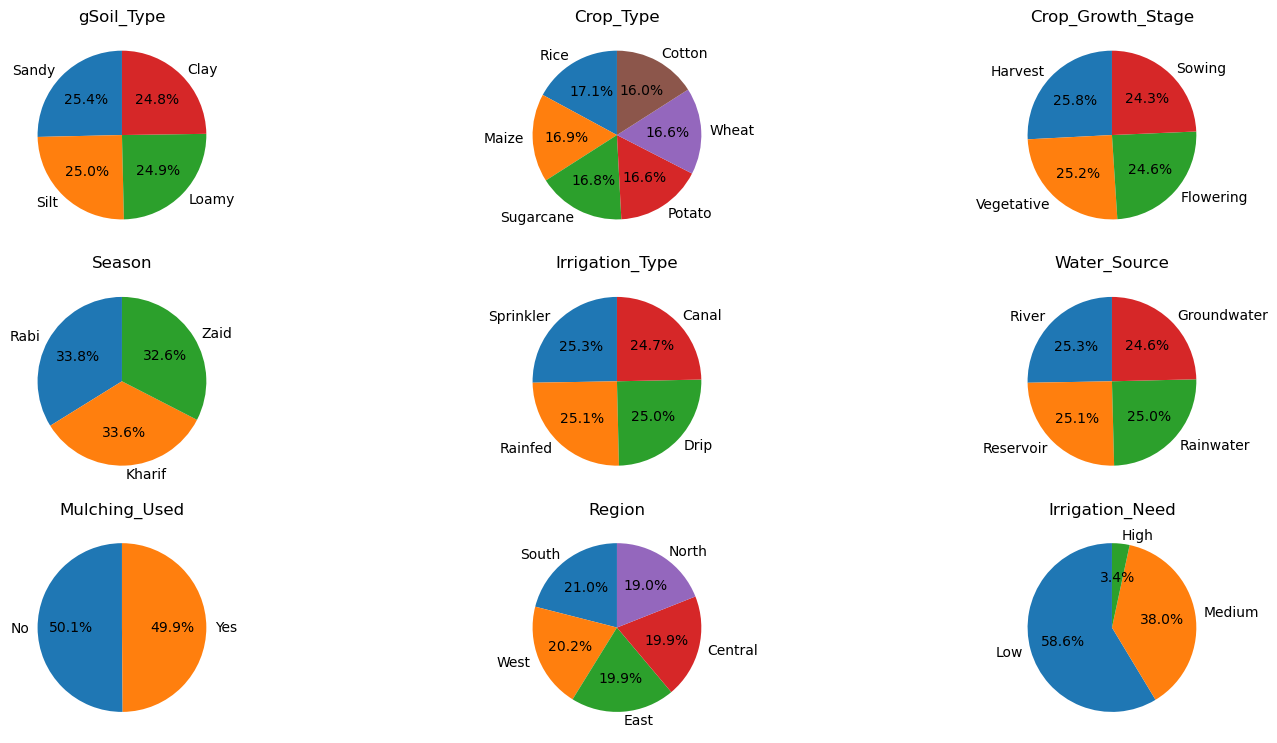

In [18]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(4,3,i+1)
    orig_df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(col)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [21]:
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
            'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
            'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

In [22]:
def engineer_features(df, moisture_map=None):
    """Create domain-driven interaction features."""
    df = df.copy()
    
    # Water balance features
    df['Total_Water_Input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    df['Evaporative_Stress'] = (df['Temperature_C'] * df['Sunlight_Hours'] * df['Wind_Speed_kmh']) / (df['Humidity'] + 1)
    df['Moisture_Deficit'] = df['Humidity'] - df['Soil_Moisture']
    df['Water_Balance'] = df['Total_Water_Input'] - df['Evaporative_Stress'] * df['Field_Area_hectare']
    
    # Crop-relative moisture (target encoding proxy - no leakage)
    if moisture_map is None:
        moisture_map = df.groupby('Crop_Type')['Soil_Moisture'].mean()
    df['Relative_Crop_Moisture'] = df['Soil_Moisture'] / df['Crop_Type'].map(moisture_map).fillna(1.0)
    
    # Mulch interaction
    df['Mulch_Moisture'] = df['Soil_Moisture'] * df['Mulching_Used'].map({'Yes': 1.5, 'No': 1.0}).fillna(1.0)
    
    # Soil health features
    df['Soil_Health'] = df['Organic_Carbon'] * df['Soil_Moisture'] / (df['Electrical_Conductivity'] + 0.1)
    df['Soil_Salinity_Risk'] = df['Electrical_Conductivity'] * df['Temperature_C'] / (df['Rainfall_mm'] + 1)
    df['pH_Deviation'] = np.abs(df['Soil_pH'] - 6.5)
    
    # Climate stress features
    df['Heat_Stress'] = df['Temperature_C'] * (100 - df['Humidity']) / 100
    df['Dryness_Index'] = df['Temperature_C'] * df['Sunlight_Hours'] / (df['Rainfall_mm'] + 1)
    df['Wind_Evap'] = df['Wind_Speed_kmh'] * df['Temperature_C'] / (df['Humidity'] + 1)
    
    # Field efficiency
    df['Irrigation_Per_Hectare'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 0.1)
    df['Rainfall_Per_Hectare'] = df['Rainfall_mm'] / (df['Field_Area_hectare'] + 0.1)
    
    # Moisture retention
    df['Moisture_Retention'] = df['Soil_Moisture'] * df['Organic_Carbon']
    df['Moisture_Temp_Ratio'] = df['Soil_Moisture'] / (df['Temperature_C'] + 1)
    
    # Crop-soil-season interactions (encoded as grouped stats)
    for grp_col in ['Soil_Type', 'Season', 'Crop_Growth_Stage']:
        grp_key = f'{grp_col}_Moisture_mean'
        if moisture_map is not None and grp_key in moisture_map.index.names:
            pass  # skip if already computed
        grp = df.groupby(grp_col)['Soil_Moisture'].transform('mean')
        df[f'{grp_col}_Moisture_dev'] = df['Soil_Moisture'] - grp
    
    return df, moisture_map

In [23]:
train_full, moisture_map = engineer_features(train_full)
test_df, _ = engineer_features(test_df, moisture_map)

feature_cols = [c for c in train_full.columns if c not in ['id', 'Irrigation_Need'] and train_full[c].dtype != 'object']
# Add back cat cols
feature_cols = cat_cols + [c for c in feature_cols if c not in cat_cols]

print(f'Total features: {len(feature_cols)}')
print(f'Engineered features: {[c for c in feature_cols if c not in cat_cols + num_cols]}')

Total features: 38
Engineered features: ['Total_Water_Input', 'Evaporative_Stress', 'Moisture_Deficit', 'Water_Balance', 'Relative_Crop_Moisture', 'Mulch_Moisture', 'Soil_Health', 'Soil_Salinity_Risk', 'pH_Deviation', 'Heat_Stress', 'Dryness_Index', 'Wind_Evap', 'Irrigation_Per_Hectare', 'Rainfall_Per_Hectare', 'Moisture_Retention', 'Moisture_Temp_Ratio', 'Soil_Type_Moisture_dev', 'Season_Moisture_dev', 'Crop_Growth_Stage_Moisture_dev']


## Target and Categorical Encoding

In [24]:
# Encode target
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
y = train_full['Irrigation_Need'].map(target_mapping).values

# Unify categories across train/test
for col in cat_cols:
    combined_cats = pd.concat([train_full[col], test_df[col]]).astype(str).unique()
    train_full[col] = pd.Categorical(train_full[col].astype(str), categories=combined_cats)
    test_df[col] = pd.Categorical(test_df[col].astype(str), categories=combined_cats)

X_train = train_full[feature_cols].copy()
X_test = test_df[feature_cols].copy()
test_ids = test_df['id'].values

for c in cat_cols:
    X_train[c] = X_train[c].astype('category')
    X_test[c] = X_test[c].astype('category')

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Target distribution: {np.bincount(y)} (Low/Medium/High = {np.bincount(y)/len(y)*100})')

X_train: (640000, 38), X_test: (270000, 38)
Target distribution: [375781 242874  21345] (Low/Medium/High = [58.71578125 37.9490625   3.33515625])


['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'id']


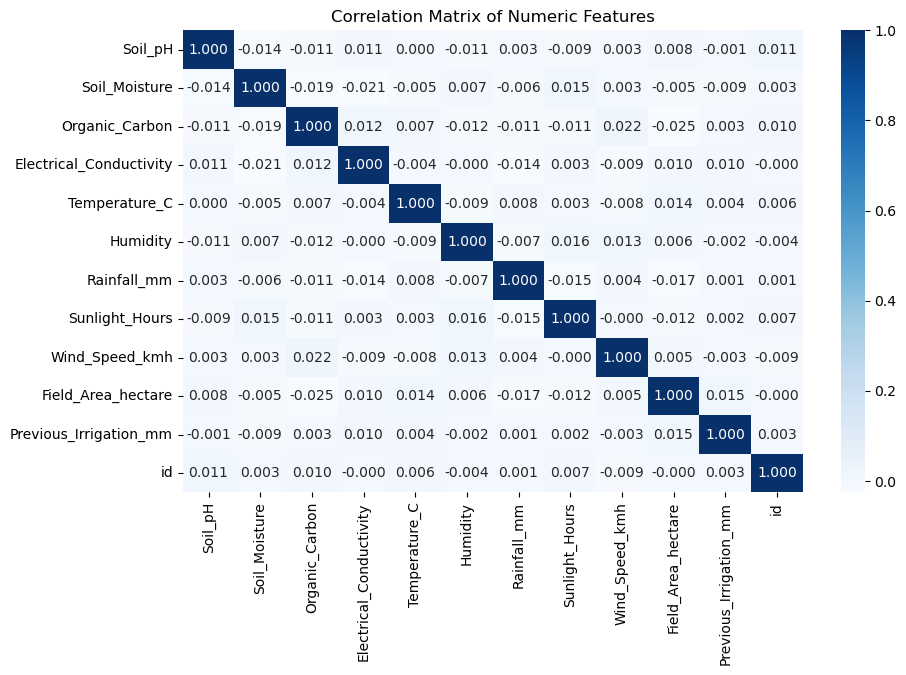

In [29]:
import matplotlib.pyplot as plt
# Compute correlation matrix for numeric features
corr_matrix = orig_df.corr(numeric_only=True)

print(corr_matrix.columns.tolist())
# Focus on correlations with the target variable (Irrigation_Need)
# IrrigationNeed_corr = corr_matrix[['Irrigation_Need']].sort_values(by='Irrigation_Need', ascending=False)

# Plot Heatmap of correlations with the target
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Blues')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [ ]:
# 3 models, GPU-accelerated, shallow trees for speed
# LightGBM
lgb_params = dict(
    device='gpu',
    n_estimators=500,
    learning_rate=0.1,
    num_leaves=31, 
    max_depth=6, 
    class_weight='balanced',
    verbose=-1
)
# XGBoost
xgb_params = dict(
    device='cuda',
    tree_method='hist',
    enable_categorical=True,
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6
)
# CatBoost (shallow & fast like the 0.967 notebook)
cat_params = dict(
    task_type='GPU',
    iterations=300,
    learning_rate=0.1,
    depth=5,
    auto_class_weights='Balanced',
    cat_features=cat_cols, verbose=0
)

model_configs = [
    ('lgb', lgb.LGBMClassifier, lgb_params, False),
    ('xgb', xgb.XGBClassifier, xgb_params, True),
    ('cat', cb.CatBoostClassifier, cat_params, False),
]

print(f'{len(model_configs)} model configs ready')

3 model configs ready


## 5-Fold CV Training with All Models

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
sample_weights = compute_sample_weight('balanced', y)

# Storage for OOF and test predictions
n_models = len(model_configs)
oof_preds = {name: np.zeros((len(X_train), 3)) for name, _, _, _ in model_configs}
test_preds = {name: np.zeros((len(X_test), 3)) for name, _, _, _ in model_configs}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    yt, yv = y[tr_idx], y[val_idx]
    wt = sample_weights[tr_idx]
    
    for name, ModelClass, params, use_sample_weight in model_configs:
        model = ModelClass(**params)
        
        if use_sample_weight:
            model.fit(xt, yt, sample_weight=wt)
        else:
            model.fit(xt, yt)
        
        oof_preds[name][val_idx] = model.predict_proba(xv)
        test_preds[name] += model.predict_proba(X_test) / N_FOLDS
        
        score = balanced_accuracy_score(yv, oof_preds[name][val_idx].argmax(1))
        print(f'  {name}: {score:.5f}')

# Print overall CV scores
print(f'\n=== Overall OOF Balanced Accuracy ===')
for name in oof_preds:
    score = balanced_accuracy_score(y, oof_preds[name].argmax(1))
    print(f'  {name}: {score:.5f}')


=== Fold 1/5 ===
  lgb: 0.96891
  xgb: 0.96934
  cat: 0.96997

=== Fold 2/5 ===
  lgb: 0.96906
  xgb: 0.96945
  cat: 0.96871

=== Fold 3/5 ===
  lgb: 0.96953
  xgb: 0.96992
  cat: 0.96922

=== Fold 4/5 ===
  lgb: 0.96889
  xgb: 0.97044
  cat: 0.97012

=== Fold 5/5 ===
  lgb: 0.96528
  xgb: 0.96482
  cat: 0.96588

=== Overall OOF Balanced Accuracy ===
  lgb: 0.96833
  xgb: 0.96879
  cat: 0.96878


In [ ]:
# Level 2: Stack with Logistic Regression
oof_stack = np.hstack([oof_preds[name] for name in oof_preds])
test_stack = np.hstack([test_preds[name] for name in test_preds])
print(f'Meta-features: {oof_stack.shape[1]} (3 probs x {n_models} models)')

# Simple average baseline
avg_oof = np.mean([oof_preds[name] for name in oof_preds], axis=0)
avg_test = np.mean([test_preds[name] for name in test_preds], axis=0)
avg_score = balanced_accuracy_score(y, avg_oof.argmax(1))
print(f'Simple average OOF balanced accuracy: {avg_score:.5f}')

# Stacked meta-learner with CV
meta_oof_preds = np.zeros(len(y), dtype=int)
meta_test_probs = np.zeros((len(X_test), 3))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    meta = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
    meta.fit(oof_stack[tr_idx], y[tr_idx])
    meta_oof_preds[val_idx] = meta.predict(oof_stack[val_idx])
    meta_test_probs += meta.predict_proba(test_stack) / N_FOLDS

stack_score = balanced_accuracy_score(y, meta_oof_preds)
print(f'Stacked meta-learner OOF balanced accuracy: {stack_score:.5f}')

# Also train final meta-model on all data
final_meta = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
final_meta.fit(oof_stack, y)
final_meta_test = final_meta.predict_proba(test_stack)

# Pick best approach
if stack_score >= avg_score:
    print('\n>>> Using stacked meta-learner predictions')
    final_test_probs = final_meta_test
    best_oof_probs = np.zeros((len(y), 3))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        meta = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
        meta.fit(oof_stack[tr_idx], y[tr_idx])
        best_oof_probs[val_idx] = meta.predict_proba(oof_stack[val_idx])
else:
    print('\n>>> Using simple average predictions')
    final_test_probs = avg_test
    best_oof_probs = avg_oof

Meta-features: 9 (3 probs x 3 models)
Simple average OOF balanced accuracy: 0.96924
Stacked meta-learner OOF balanced accuracy: 0.97115

>>> Using stacked meta-learner predictions


## Threshold Optimization for Balanced Accuracy

In [ ]:
# Optimize class weights applied to probabilities for balanced accuracy
# High class (idx 2) is rare (3.3%), so boosting its weight helps balanced accuracy
best_w = [1.0, 1.0, 1.0]
best_adj_score = balanced_accuracy_score(y, best_oof_probs.argmax(1))

for w_high in np.arange(1.0, 5.1, 0.2):
    for w_med in np.arange(0.8, 1.6, 0.1):
        w = np.array([1.0, w_med, w_high])  # Low=0, Medium=1, High=2
        adjusted = best_oof_probs * w[np.newaxis, :]
        preds = adjusted.argmax(axis=1)
        score = balanced_accuracy_score(y, preds)
        if score > best_adj_score:
            best_adj_score = score
            best_w = w.tolist()

print(f'Best class weights: Low={best_w[0]:.1f}, Medium={best_w[1]:.1f}, High={best_w[2]:.1f}')
print(f'Adjusted OOF balanced accuracy: {best_adj_score:.5f}')
print(f'Improvement over raw: +{best_adj_score - balanced_accuracy_score(y, best_oof_probs.argmax(1)):.5f}')

Best class weights: Low=1.0, Medium=1.0, High=1.4
Adjusted OOF balanced accuracy: 0.97142
Improvement over raw: +0.00027


## Analysis and Visualizations

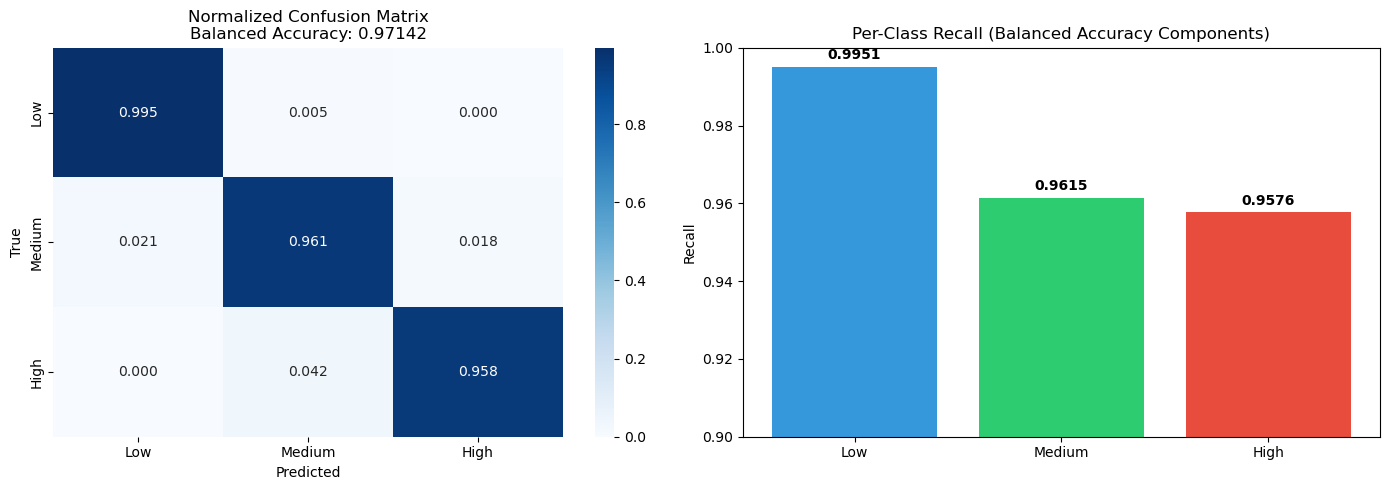


Classification Report:
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    375781
      Medium       0.99      0.96      0.97    242874
        High       0.83      0.96      0.89     21345

    accuracy                           0.98    640000
   macro avg       0.93      0.97      0.95    640000
weighted avg       0.98      0.98      0.98    640000



In [ ]:
# Confusion Matrix
adjusted_oof = best_oof_probs * np.array(best_w)[np.newaxis, :]
oof_final = adjusted_oof.argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, oof_final, normalize='true')
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_title(f'Normalized Confusion Matrix\nBalanced Accuracy: {best_adj_score:.5f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

recalls = cm.diagonal()
colors = ['#3498db', '#2ecc71', '#e74c3c']
axes[1].bar(['Low', 'Medium', 'High'], recalls, color=colors)
axes[1].set_title('Per-Class Recall (Balanced Accuracy Components)')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0.9, 1.0)
for i, (cls, r) in enumerate(zip(['Low', 'Medium', 'High'], recalls)):
    axes[1].text(i, r + 0.002, f'{r:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y, oof_final, target_names=['Low', 'Medium', 'High']))

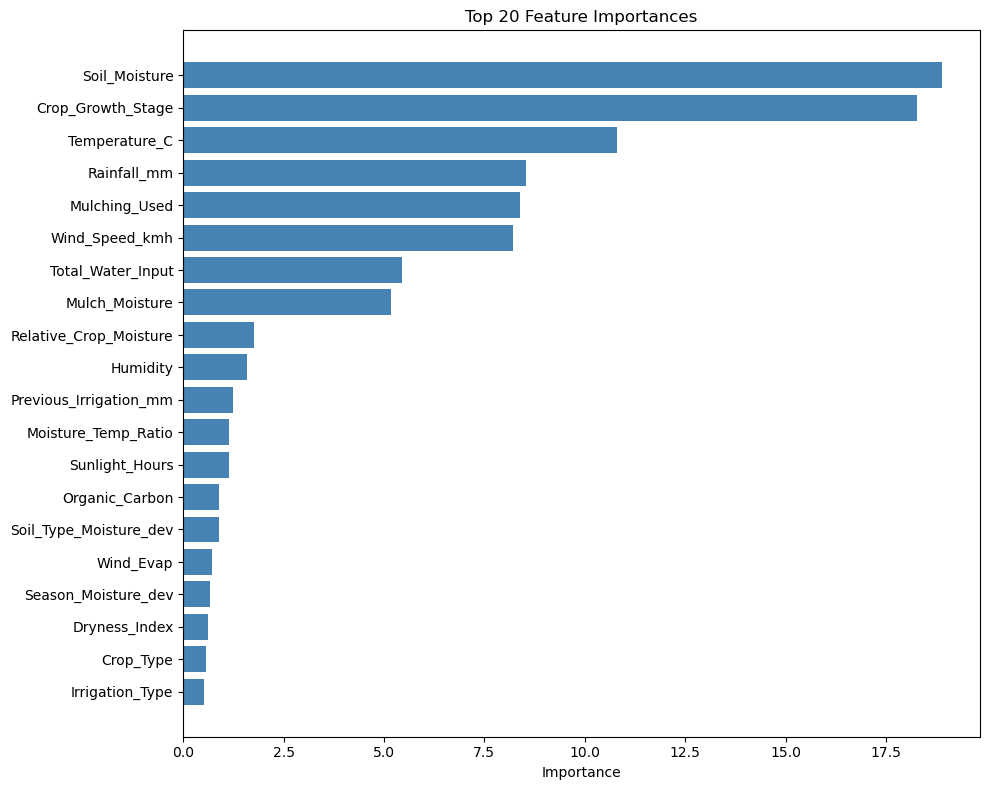

In [ ]:
# Feature importance (from last LightGBM model)
fi = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_ if hasattr(model, 'feature_importances_') else np.zeros(len(feature_cols))
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi['feature'], fi['importance'], color='steelblue')
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()